# Data analysis for Real User qurries

In [2]:
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns
import catppuccin
import numpy as np
import json
sns.set_theme(style="whitegrid")
plt.style.use(catppuccin.PALETTE.latte.identifier)

## Preprosses

In [ ]:
shared_lang_list = ["zh", "ko", "es", "fr", "ja", "id", "vi", "uk", "ro", "no"]

In [ ]:
shared_lang_list_high = ["zh", "ko", "es", "fr", "ja", "vi", "id"]
shared_lang_list_low = ["uk", "ro", "no"]

In [ ]:
list_of_judge_models = ["claude-opus-4.7", "gemini-3.5-flash", "gpt-5.5"]

In [ ]:
path_to_results = "../benchmarks/results-main"

In [ ]:
def process_file(model_judge):
    df = pd.read_csv(f"{path_to_results}/accuracy_shareGPT_{model_judge}.csv", header=None)
    df.columns = ["model", "model_judge" ,"prompt_type", "lang", "num", "accuracy"]
    
    
    df = df.drop_duplicates(subset=["model", "model_judge", "prompt_type", "lang", "num"], keep="last")
    
    # create df with lang and num, drop duplicates, reset index
    df_lang_num = df[["lang", "num"]]
    df_lang_num = df_lang_num.drop_duplicates(subset=["lang", "num"], keep="last")
    df_lang_num.sort_values("lang", inplace=True)
    df_lang_num.set_index("lang", inplace=True)
    
    df = df.pivot_table(
        index=[
            "model",
            "prompt_type",
        ],
        columns="lang",
        values="accuracy",
    )
    df = df.reset_index()
    column_names = [
        "model",
        "prompt_type",
    ] + shared_lang_list
    df = df.reindex(columns=column_names)

    # Assume 'column_name' is the column you want to sort and 'specific_order' is the list specifying the order
    df["prompt_type"] = pd.Categorical(
        df["prompt_type"],
        categories=[
            "direct",
            "adamic",
            "adamic_self_trans"
        ],
        ordered=True,
    )
    # df['model'] = pd.Categorical(df['model'], categories=["gpt-3.5-turbo-1106","bigscience/bloomz-7b1","mistralai/Mistral-7B-Instruct-v0.2","meta-llama/Llama-2-13b-chat-hf","TheBloke/Llama-2-70B-Chat-AWQ","ybelkada/Mixtral-8x7B-Instruct-v0.1-AWQ"], ordered=True)
    # Then you can sort the DataFrame by 'column_name'
    df = df.sort_values(
        [
            "model",
            "prompt_type",
        ]
    )
    # dont need weight for high resource languages, since they all have the same number of samples; 100 samples per language
    df["AVG - high"] = np.average(df[shared_lang_list_high], axis=1
                                  )
    df["AVG - low"] = np.average(df[shared_lang_list_low], weights=df_lang_num.loc[shared_lang_list_low, "num"].to_list(), axis=1)
    df["AVG - all"] = np.average(df[shared_lang_list], weights=df_lang_num.loc[shared_lang_list, "num"].to_list(), axis=1)

    df = df.reset_index(drop=True)
    # save df to csv
    df.to_csv(f"{path_to_results}/accuracy_processed/accuracy_shareGPT_{model_judge}_pivot.csv")

In [ ]:
for model_judge in list_of_judge_models:
    process_file(model_judge)

## create main table with high and low resource

In [ ]:
shared_lang_list_all = ["zh", "ko", "es", "fr", "ja", "id", "vi", "uk", "ro", "no"]
shared_lang_list_high = ["zh", "ko", "es", "fr", "ja", "vi", "id"]
shared_lang_list_low = ["uk", "ro", "no"]
list_of_judge_models = ["claude-opus-4.7", "gemini-3.5-flash", "gpt-5.5"]

In [ ]:
def create_table_per_task(judge_model, tables_dir):
    task = f"shareGPT_{judge_model}"
    df = pd.read_csv(f"{path_to_results}/accuracy_processed/accuracy_{task}_pivot.csv", index_col=0)
    
    
    # rename columns
    df.rename(columns={"model": "Model", "prompt_type": "Prompt Type"}, inplace=True)
    
    # rename models to more readable names
    df["Model"] = df["Model"].replace("adamic_graph_self_translate/llama-4-scout-17b-16e-instruct", "Llama-4-Scout-17B")
    df["Model"] = df["Model"].replace("adamic_graph_self_translate/gpt-oss-120b", "GPT-OSS-120B")
    df["Model"] = df["Model"].replace("adamic_graph_self_translate/deepseek-v4-pro", "DeepSeek-V4-Pro")
    df["Model"] = df["Model"].replace("adamic_graph_self_translate/claude-opus-4.7", "Claude-Opus-4.7")
    df["Model"] = df["Model"].replace("adamic_graph/claude-opus-4.7", "Claude-Opus-4.7")
    df["Model"] = df["Model"].replace("adamic_graph/gpt-oss-120b", "GPT-OSS-120B")
    df["Model"] = df["Model"].replace("adamic_graph/llama-4-scout-17b-16e-instruct", "Llama-4-Scout-17B")
    df["Model"] = df["Model"].replace("adamic_graph/deepseek-v4-pro", "DeepSeek-V4-Pro")
    df["Model"] = df["Model"].replace("deepseek/deepseek-v4-pro", "DeepSeek-V4-Pro")
    df["Model"] = df["Model"].replace("anthropic/claude-opus-4.7", "Claude-Opus-4.7")
    df["Model"] = df["Model"].replace("meta-llama/llama-4-scout-17b-16e-instruct", "Llama-4-Scout-17B")
    df["Model"] = df["Model"].replace("openai/gpt-oss-120b", "GPT-OSS-120B")
    
    # rename prompt types to more readable names
    df["Prompt Type"] = df["Prompt Type"].replace("direct", "Native")
    df["Prompt Type"] = df["Prompt Type"].replace("adamic", "Adamic NMT")
    df["Prompt Type"] = df["Prompt Type"].replace("adamic_self_trans", "Adamic Self-Trans")
    
    # sort by model and prompt type
    df = df.sort_values(
        [
            "Model",
            "Prompt Type",
        ]
    )
    
    #make a rounded version of the table for better visualization in the paper
    df_rounded = df.copy()
    for col in df.columns:
        if col not in ["Model", "Prompt Type"]:
            df_rounded[col] = df[col].round(3)
    # save the table to the specified directory
    df.to_csv(f"{tables_dir}/{task}_table.csv", index=False)
    df_rounded.to_csv(f"{tables_dir}/{task}_table_rounded.csv", index=False)

In [ ]:
for model_judge in list_of_judge_models:
    create_table_per_task(model_judge, "../benchmarks/result_tables")

In [ ]:
df = pd.read_csv("../benchmarks/result_tables/shareGPT_gpt-5.5_table.csv")
df_rounded = pd.read_csv("../benchmarks/result_tables/shareGPT_gpt-5.5_table_rounded.csv")

In [ ]:
df_rounded

### Create "lang" main with the average rating of all judges for each model and language

In [32]:
df_lang_main = pd.read_csv("../benchmarks/result_tables/shareGPT_claude-opus-4.7_table.csv")

In [33]:
df_lang_main

,Model,Prompt Type,zh,ko,es,fr,ja,id,vi,uk,ro,no,AVG - high,AVG - low,AVG - all
0,Claude-Opus-4.7,Adamic NMT,8.600000,8.30,8.42,8.62,8.29,8.62,8.70,8.806122,8.509434,8.547170,8.507143,8.661765,8.542035
1,Claude-Opus-4.7,Adamic Self-Trans,8.720000,8.70,8.70,8.74,8.65,8.75,8.84,8.887755,8.735849,8.754717,8.728571,8.813725,8.747788
2,Claude-Opus-4.7,Native,8.810000,8.66,8.85,8.82,8.62,8.77,8.85,8.806122,8.471698,8.754717,8.768571,8.705882,8.754425
3,DeepSeek-V4-Pro,Adamic NMT,7.320000,6.72,7.34,7.78,7.08,7.54,7.58,7.510204,7.207547,7.716981,7.337143,7.485294,7.370575
4,DeepSeek-V4-Pro,Adamic Self-Trans,7.790000,7.21,7.78,7.69,7.25,7.74,7.85,7.816327,7.094340,7.754717,7.615714,7.612745,7.615044
5,DeepSeek-V4-Pro,Native,8.550000,8.06,8.41,8.36,8.30,8.69,8.67,8.704082,8.245283,8.698113,8.434286,8.583333,8.467920
6,GPT-OSS-120B,Adamic NMT,6.980000,6.90,7.44,7.46,6.59,7.53,7.30,7.183673,6.641509,7.207547,7.171429,7.049020,7.143805
7,GPT-OSS-120B,Adamic Self-Trans,7.500000,7.39,7.72,7.61,7.30,7.64,7.33,7.836735,7.056604,7.471698,7.498571,7.539216,7.507743
8,GPT-OSS-120B,Native,7.760000,7.57,7.64,7.79,7.24,7.90,7.71,7.959184,6.943396,7.094340,7.658571,7.470588,7.616150
9,Llama-4-Scout-17B,Adamic NMT,6.070707,6.12,5.94,6.35,5.69,6.39,6.43,6.612245,6.150943,5.962264,6.141530,6.323529,6.182600


In [34]:
df_opus = df_lang_main.copy()
df_gpt = pd.read_csv("../benchmarks/result_tables/shareGPT_gpt-5.5_table.csv")
df_gemini = pd.read_csv("../benchmarks/result_tables/shareGPT_gemini-3.5-flash_table.csv")

In [21]:
df_lang_main.loc[1, "zh"]

np.float64(87.2)

In [35]:
for lang in shared_lang_list:
    for i,row in enumerate(df_lang_main[lang].to_list()):
        df_lang_main.loc[i, lang] = np.mean([df_opus.loc[i, lang], df_gpt.loc[i, lang], df_gemini.loc[i, lang]])

In [36]:
df_lang_main

,Model,Prompt Type,zh,ko,es,fr,ja,id,vi,uk,ro,no,AVG - high,AVG - low,AVG - all
0,Claude-Opus-4.7,Adamic NMT,8.886667,8.613333,8.543333,8.793333,8.526667,8.746667,8.886667,9.081633,8.635220,8.830189,8.507143,8.661765,8.542035
1,Claude-Opus-4.7,Adamic Self-Trans,9.028485,8.906667,8.830842,8.803333,8.863333,8.856667,9.004916,9.125850,8.729560,8.924528,8.728571,8.813725,8.747788
2,Claude-Opus-4.7,Native,9.049192,8.786667,8.930000,8.876667,8.783333,8.810000,8.976667,9.061224,8.654088,8.924528,8.768571,8.705882,8.754425
3,DeepSeek-V4-Pro,Adamic NMT,7.983333,7.694510,7.722222,8.135000,7.614343,8.095222,8.059327,8.163406,7.836478,8.126918,7.337143,7.485294,7.370575
4,DeepSeek-V4-Pro,Adamic Self-Trans,8.403946,7.897831,8.269504,8.143931,7.838056,8.141154,8.283643,8.453643,7.823899,8.163522,7.615714,7.612745,7.615044
5,DeepSeek-V4-Pro,Native,8.900000,8.393333,8.631246,8.613333,8.670000,8.783333,8.890000,9.057823,8.496855,8.849057,8.434286,8.583333,8.467920
6,GPT-OSS-120B,Adamic NMT,7.523426,7.505051,7.744717,7.879622,7.203401,7.880000,7.637267,7.853741,7.247996,7.606569,7.171429,7.049020,7.143805
7,GPT-OSS-120B,Adamic Self-Trans,8.065942,7.931837,8.021768,8.026667,7.716162,8.058841,7.674570,8.385020,7.786164,7.918239,7.498571,7.539216,7.507743
8,GPT-OSS-120B,Native,8.201145,8.089865,7.928611,8.098231,7.680000,8.065960,7.878610,8.288478,7.515723,7.489478,7.658571,7.470588,7.616150
9,Llama-4-Scout-17B,Adamic NMT,6.683081,6.664820,6.403867,6.852646,6.085960,6.863333,6.801777,7.117630,6.874214,6.477987,6.141530,6.323529,6.182600


In [37]:
path_to_tables = "../benchmarks/result_tables"

#### Get weighted average for each language high, low resource and all 

In [24]:
path_to_tables = "../benchmarks/result_tables"

In [27]:
path_to_results = "../benchmarks/results-main"

In [38]:
df_lang_main.drop(columns=["AVG - high", "AVG - low", "AVG - all"], inplace=True)

In [39]:
df_temp = pd.read_csv(f"{path_to_results}/accuracy_shareGPT_{list_of_judge_models[0]}.csv", header=None)
df_temp.columns = ["model", "model_judge" ,"prompt_type", "lang", "num", "accuracy"]


df_temp = df_temp.drop_duplicates(subset=["model", "model_judge", "prompt_type", "lang", "num"], keep="last")

# create df with lang and num, drop duplicates, reset index
df_lang_num = df_temp[["lang", "num"]]
df_lang_num = df_lang_num.drop_duplicates(subset=["lang", "num"], keep="last")
df_lang_num.sort_values("lang", inplace=True)
df_lang_num.set_index("lang", inplace=True)

In [40]:
df_lang_main["AVG - high"] = np.average(df_lang_main[shared_lang_list_high], axis=1) # dont need weight for high resource languages, since they all have the same number of samples; 100 samples per language
df_lang_main["AVG - low"] = np.average(df_lang_main[shared_lang_list_low], weights=df_lang_num.loc[shared_lang_list_low, "num"].to_list(), axis=1)
df_lang_main["AVG - all"] = np.average(df_lang_main[shared_lang_list], weights=df_lang_num.loc[shared_lang_list, "num"].to_list(), axis=1)

In [41]:
df_lang_main

,Model,Prompt Type,zh,ko,es,fr,ja,id,vi,uk,ro,no,AVG - high,AVG - low,AVG - all
0,Claude-Opus-4.7,Adamic NMT,8.886667,8.613333,8.543333,8.793333,8.526667,8.746667,8.886667,9.081633,8.635220,8.830189,8.713810,8.900327,8.755900
1,Claude-Opus-4.7,Adamic Self-Trans,9.028485,8.906667,8.830842,8.803333,8.863333,8.856667,9.004916,9.125850,8.729560,8.924528,8.899177,8.970588,8.915292
2,Claude-Opus-4.7,Native,9.049192,8.786667,8.930000,8.876667,8.783333,8.810000,8.976667,9.061224,8.654088,8.924528,8.887504,8.919935,8.894822
3,DeepSeek-V4-Pro,Adamic NMT,7.983333,7.694510,7.722222,8.135000,7.614343,8.095222,8.059327,8.163406,7.836478,8.126918,7.900565,8.068989,7.938572
4,DeepSeek-V4-Pro,Adamic Self-Trans,8.403946,7.897831,8.269504,8.143931,7.838056,8.141154,8.283643,8.453643,7.823899,8.163522,8.139723,8.214659,8.156634
5,DeepSeek-V4-Pro,Native,8.900000,8.393333,8.631246,8.613333,8.670000,8.783333,8.890000,9.057823,8.496855,8.849057,8.697321,8.857843,8.733545
6,GPT-OSS-120B,Adamic NMT,7.523426,7.505051,7.744717,7.879622,7.203401,7.880000,7.637267,7.853741,7.247996,7.606569,7.624783,7.632150,7.626446
7,GPT-OSS-120B,Adamic Self-Trans,8.065942,7.931837,8.021768,8.026667,7.716162,8.058841,7.674570,8.385020,7.786164,7.918239,7.927969,8.108163,7.968633
8,GPT-OSS-120B,Native,8.201145,8.089865,7.928611,8.098231,7.680000,8.065960,7.878610,8.288478,7.515723,7.489478,7.991775,7.880130,7.966580
9,Llama-4-Scout-17B,Adamic NMT,6.683081,6.664820,6.403867,6.852646,6.085960,6.863333,6.801777,7.117630,6.874214,6.477987,6.622212,6.888208,6.682238


In [ ]:
df_lang_main_rounded = df_lang_main.copy()
for col in df_lang_main_rounded.columns:
    if col not in ["Model", "Prompt Type"]:
        df_lang_main_rounded[col] = df_lang_main_rounded[col].round(3)
df_lang_main.to_csv(f"{path_to_tables}/shareGPT_all_langs.csv", index=False)
df_lang_main_rounded.to_csv(f"{path_to_tables}/shareGPT_all_langs_rounded.csv", index=False)

#### Get anmount of best languages for each model and prompt type

In [ ]:
amount_of_best_langs = {
    "Claude-Opus-4.7": {
        "Adamic NMT": [0, []],
        "Adamic Self-Trans": [0, []],
        "Native": [0, []],
    },
    "DeepSeek-V4-Pro": {
        "Adamic NMT": [0, []],
        "Adamic Self-Trans": [0, []],
        "Native": [0, []],
    },
    "GPT-OSS-120B": {
        "Adamic NMT": [0, []],
        "Adamic Self-Trans": [0, []],
        "Native": [0, []]},
    "Llama-4-Scout-17B": {
        "Adamic NMT": [0, []],
        "Adamic Self-Trans": [0, []],
        "Native": [0, []],
    }
}

In [ ]:
for model in df_lang_main["Model"].unique():
    for lang in shared_lang_list:
        if df_lang_main[df_lang_main[df_lang_main["Model"] == model][[lang]].max().to_list()[0] == df_lang_main[lang]]["Prompt Type"].to_list()[0] == "Adamic Self-Trans":
            amount_of_best_langs[model]["Adamic Self-Trans"][0] += 1
            amount_of_best_langs[model]["Adamic Self-Trans"][1].append(lang)
        elif df_lang_main[df_lang_main[df_lang_main["Model"] == model][[lang]].max().to_list()[0] == df_lang_main[lang]]["Prompt Type"].to_list()[0] == "Adamic NMT":
            amount_of_best_langs[model]["Adamic NMT"][0] += 1
            amount_of_best_langs[model]["Adamic NMT"][1].append(lang)
        elif df_lang_main[df_lang_main[df_lang_main["Model"] == model][[lang]].max().to_list()[0] == df_lang_main[lang]]["Prompt Type"].to_list()[0] == "Native":
            amount_of_best_langs[model]["Native"][0] += 1
            amount_of_best_langs[model]["Native"][1].append(lang)

In [ ]:
amount_of_best_langs

## Create main table with all judge results for all languages and models

In [42]:
path_to_tables = "../benchmarks/result_tables"

In [43]:
shared_lang_list_all = ["zh", "ko", "es", "fr", "ja", "id", "vi", "uk", "ro", "no"]
shared_lang_list_high = ["zh", "ko", "es", "fr", "ja", "vi", "id"]
shared_lang_list_low = ["uk", "ro", "no"]
list_of_judge_models = ["claude-opus-4.7", "gemini-3.5-flash", "gpt-5.5"]

In [44]:
df = pd.read_csv("../benchmarks/result_tables/shareGPT_claude-opus-4.7_table.csv")

In [45]:
df.rename(columns={"AVG - high": "Claude-Opus-4.7 Rating - high", "AVG - low": "Claude-Opus-4.7 Rating - low", "AVG - all": "Claude-Opus-4.7 Rating - all"}, inplace=True)
df.drop(columns=shared_lang_list_all, inplace=True)

In [46]:
df2 = pd.read_csv("../benchmarks/result_tables/shareGPT_gemini-3.5-flash_table.csv")

In [47]:
df2.rename(columns={"AVG - high": "Gemini-3.5-Flash Rating - high", "AVG - low": "Gemini-3.5-Flash Rating - low", "AVG - all": "Gemini-3.5-Flash Rating - all"}, inplace=True)
df2.drop(columns=shared_lang_list_all, inplace=True)

In [48]:
df_merged = pd.merge(df, df2, on=["Model", "Prompt Type"], how="inner")

In [49]:
df_merged

,Model,Prompt Type,Claude-Opus-4.7 Rating - high,Claude-Opus-4.7 Rating - low,Claude-Opus-4.7 Rating - all,Gemini-3.5-Flash Rating - high,Gemini-3.5-Flash Rating - low,Gemini-3.5-Flash Rating - all
0,Claude-Opus-4.7,Adamic NMT,8.507143,8.661765,8.542035,9.425714,9.622549,9.470133
1,Claude-Opus-4.7,Adamic Self-Trans,8.728571,8.813725,8.747788,9.600000,9.583333,9.596239
2,Claude-Opus-4.7,Native,8.768571,8.705882,8.754425,9.528225,9.568627,9.537342
3,DeepSeek-V4-Pro,Adamic NMT,7.337143,7.485294,7.370575,8.720662,8.991281,8.781731
4,DeepSeek-V4-Pro,Adamic Self-Trans,7.615714,7.612745,7.615044,9.002764,9.124368,9.030206
5,DeepSeek-V4-Pro,Native,8.434286,8.583333,8.467920,9.390534,9.549020,9.426298
6,GPT-OSS-120B,Adamic NMT,7.171429,7.049020,7.143805,8.461902,8.523901,8.475893
7,GPT-OSS-120B,Adamic Self-Trans,7.498571,7.539216,7.507743,8.613187,9.005862,8.701800
8,GPT-OSS-120B,Native,7.658571,7.470588,7.616150,8.757174,8.675551,8.738755
9,Llama-4-Scout-17B,Adamic NMT,6.141530,6.323529,6.182600,7.429222,7.679330,7.485663


In [50]:
df3 = pd.read_csv("../benchmarks/result_tables/shareGPT_gpt-5.5_table.csv")
df3.rename(columns={"AVG - high": "GPT-5.5 Rating - high", "AVG - low": "GPT-5.5 Rating - low", "AVG - all": "GPT-5.5 Rating - all"}, inplace=True)
df3.drop(columns=shared_lang_list_all, inplace=True)
df_merged = pd.merge(df_merged, df3, on=["Model", "Prompt Type"], how="inner")

In [51]:
df_merged

,Model,Prompt Type,Claude-Opus-4.7 Rating - high,Claude-Opus-4.7 Rating - low,Claude-Opus-4.7 Rating - all,Gemini-3.5-Flash Rating - high,Gemini-3.5-Flash Rating - low,Gemini-3.5-Flash Rating - all,GPT-5.5 Rating - high,GPT-5.5 Rating - low,GPT-5.5 Rating - all
0,Claude-Opus-4.7,Adamic NMT,8.507143,8.661765,8.542035,9.425714,9.622549,9.470133,8.208571,8.416667,8.255531
1,Claude-Opus-4.7,Adamic Self-Trans,8.728571,8.813725,8.747788,9.600000,9.583333,9.596239,8.368961,8.514706,8.401850
2,Claude-Opus-4.7,Native,8.768571,8.705882,8.754425,9.528225,9.568627,9.537342,8.365714,8.485294,8.392699
3,DeepSeek-V4-Pro,Adamic NMT,7.337143,7.485294,7.370575,8.720662,8.991281,8.781731,7.643891,7.730392,7.663411
4,DeepSeek-V4-Pro,Adamic Self-Trans,7.615714,7.612745,7.615044,9.002764,9.124368,9.030206,7.800692,7.906863,7.824651
5,DeepSeek-V4-Pro,Native,8.434286,8.583333,8.467920,9.390534,9.549020,9.426298,8.267143,8.441176,8.306416
6,GPT-OSS-120B,Adamic NMT,7.171429,7.049020,7.143805,8.461902,8.523901,8.475893,7.241020,7.323529,7.259639
7,GPT-OSS-120B,Adamic Self-Trans,7.498571,7.539216,7.507743,8.613187,9.005862,8.701800,7.672150,7.779412,7.696355
8,GPT-OSS-120B,Native,7.658571,7.470588,7.616150,8.757174,8.675551,8.738755,7.559578,7.494250,7.544836
9,Llama-4-Scout-17B,Adamic NMT,6.141530,6.323529,6.182600,7.429222,7.679330,7.485663,6.295884,6.661765,6.378450


### Get average ratings for low and high resource languages for each model and prompt type and for all languages together

In [52]:
df_merged_avg = df_merged.copy()
df_merged_avg["AVG Rating - high"] = df_merged_avg[["Claude-Opus-4.7 Rating - high", "Gemini-3.5-Flash Rating - high", "GPT-5.5 Rating - high"]].mean(axis=1)
df_merged_avg["AVG Rating - low"] = df_merged_avg[["Claude-Opus-4.7 Rating - low", "Gemini-3.5-Flash Rating - low", "GPT-5.5 Rating - low"]].mean(axis=1)
df_merged_avg["AVG Rating - all"] = df_merged_avg[["Claude-Opus-4.7 Rating - all", "Gemini-3.5-Flash Rating - all", "GPT-5.5 Rating - all"]].mean(axis=1)

In [53]:
df_merged_avg_with_judge_all = df_merged_avg.copy()


In [54]:
df_merged_avg.drop(columns=["Claude-Opus-4.7 Rating - all", "Gemini-3.5-Flash Rating - all", "GPT-5.5 Rating - all"], inplace=True)

In [56]:
df_merged_avg

,Model,Prompt Type,Claude-Opus-4.7 Rating - high,Claude-Opus-4.7 Rating - low,Gemini-3.5-Flash Rating - high,Gemini-3.5-Flash Rating - low,GPT-5.5 Rating - high,GPT-5.5 Rating - low,AVG Rating - high,AVG Rating - low,AVG Rating - all
0,Claude-Opus-4.7,Adamic NMT,8.507143,8.661765,9.425714,9.622549,8.208571,8.416667,8.713810,8.900327,8.755900
1,Claude-Opus-4.7,Adamic Self-Trans,8.728571,8.813725,9.600000,9.583333,8.368961,8.514706,8.899177,8.970588,8.915292
2,Claude-Opus-4.7,Native,8.768571,8.705882,9.528225,9.568627,8.365714,8.485294,8.887504,8.919935,8.894822
3,DeepSeek-V4-Pro,Adamic NMT,7.337143,7.485294,8.720662,8.991281,7.643891,7.730392,7.900565,8.068989,7.938572
4,DeepSeek-V4-Pro,Adamic Self-Trans,7.615714,7.612745,9.002764,9.124368,7.800692,7.906863,8.139723,8.214659,8.156634
5,DeepSeek-V4-Pro,Native,8.434286,8.583333,9.390534,9.549020,8.267143,8.441176,8.697321,8.857843,8.733545
6,GPT-OSS-120B,Adamic NMT,7.171429,7.049020,8.461902,8.523901,7.241020,7.323529,7.624783,7.632150,7.626446
7,GPT-OSS-120B,Adamic Self-Trans,7.498571,7.539216,8.613187,9.005862,7.672150,7.779412,7.927969,8.108163,7.968633
8,GPT-OSS-120B,Native,7.658571,7.470588,8.757174,8.675551,7.559578,7.494250,7.991775,7.880130,7.966580
9,Llama-4-Scout-17B,Adamic NMT,6.141530,6.323529,7.429222,7.679330,6.295884,6.661765,6.622212,6.888208,6.682238


In [55]:
df_merged_avg_rounded = df_merged_avg.copy()
for col in df_merged_avg_rounded.columns:
    if col not in ["Model", "Prompt Type"]:
        df_merged_avg_rounded[col] = df_merged_avg_rounded[col].round(3)

In [ ]:
df_merged_avg.to_csv(f"{path_to_tables}/shareGPT_main.csv", index=False)
df_merged_avg_rounded.to_csv(f"{path_to_tables}/shareGPT_main_rounded.csv", index=False)

## Barplot 

In [58]:
path_to_tables = "../benchmarks/result_tables"

In [59]:
df_main = pd.read_csv(f"{path_to_tables}/shareGPT_main.csv")

In [60]:
df_main = df_main.sort_values(by=["Model", "Prompt Type"], ascending=[False, True])

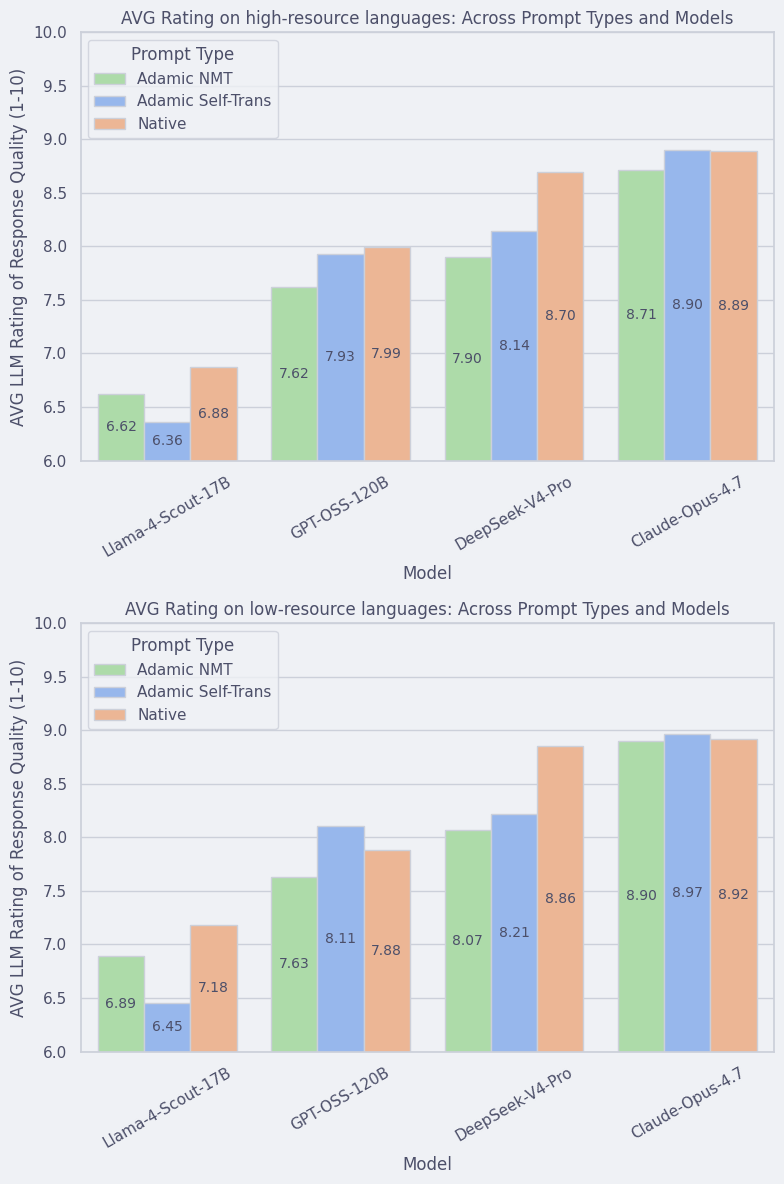

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

df_plot = df_main[df_main["Prompt Type"].isin(["Adamic Self-Trans", "Native", "Adamic NMT"])]
# Catppuccin Mocha palette
catppuccin_colors = [
    "#89b4fa",  # blue
    "#fab387",  # peach
    "#a6e3a1",  # green
    "#f38ba8",  # red/pink
]

for ax, col, title in [
    (axes[0], "AVG Rating - high", "AVG Rating on high-resource languages: Across Prompt Types and Models"),
    (axes[1], "AVG Rating - low", "AVG Rating on low-resource languages: Across Prompt Types and Models"),
]:
    sns.barplot(data=df_plot, x="Model", y=col, hue="Prompt Type", ax=ax, palette=dict(zip(["Adamic Self-Trans", "Native", "Adamic NMT"], catppuccin_colors)))
    sns.move_legend(ax, "upper left")
    ax.set_title(title)
    ax.set_ylim(6, 10)
    ax.set_ylabel("AVG LLM Rating of Response Quality (1-10)")
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.tick_params(axis='x', rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="center", fontsize=10,)

plt.tight_layout()
plt.show()

In [62]:
fig.savefig("fig_admic_performance_uq.pdf", bbox_inches="tight", transparent=True)

In [63]:
df_main_with_judge_all = df_merged_avg_with_judge_all
df_main_with_judge_all = df_main_with_judge_all.sort_values(by=["Model", "Prompt Type"], ascending=[False, True])

df_judge_list = ["Claude-Opus-4.7", "Gemini-3.5-Flash", "GPT-5.5"]

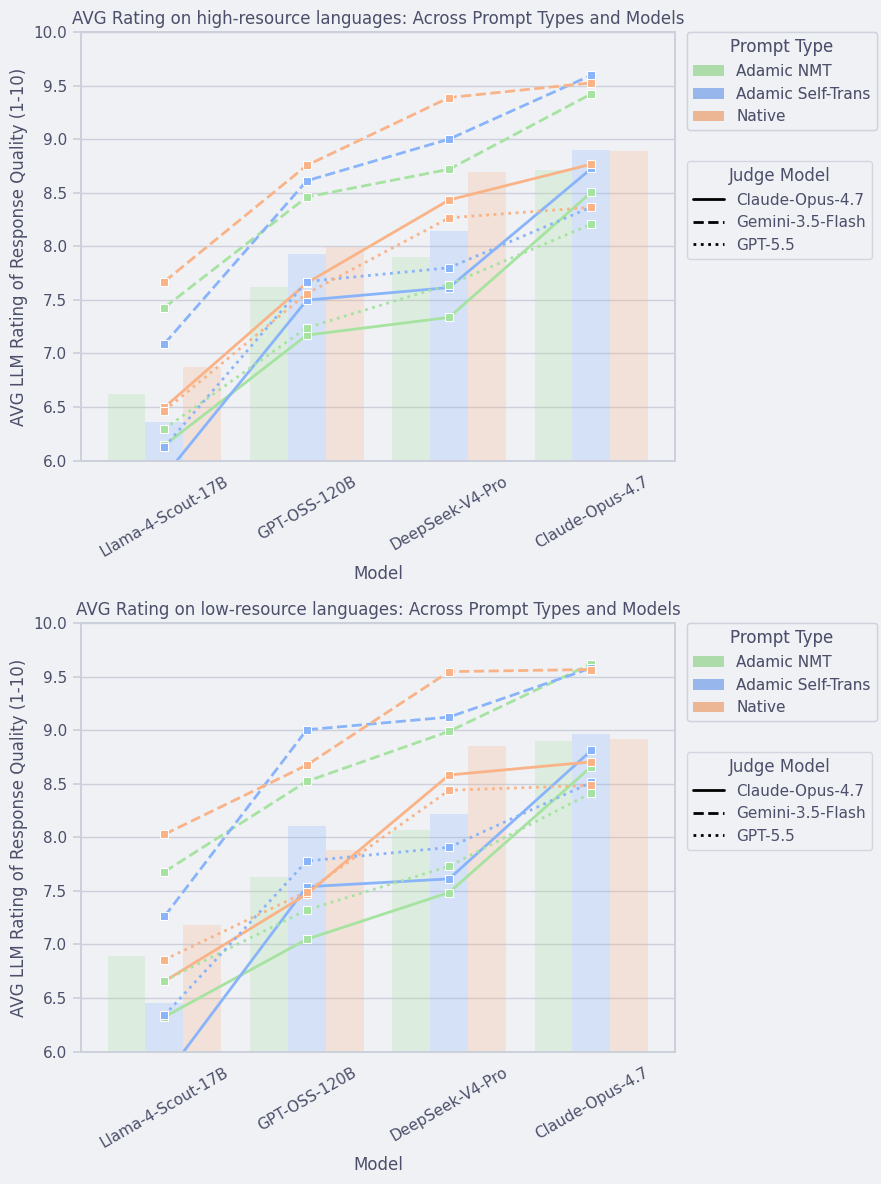

In [67]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 1, figsize=(9, 12))

dash_styles = ["-", "--", ":"]

prompt_types_order = ["Adamic NMT","Adamic Self-Trans", "Native"]

df_plot = df_main[df_main["Prompt Type"].isin(prompt_types_order)]
df_line_plot = df_main_with_judge_all[df_main_with_judge_all["Prompt Type"].isin(prompt_types_order)]

catppuccin_colors_for_line = {
    "Adamic Self-Trans": "#89b4fa",
    "Native": "#fab387",
    "Adamic NMT": "#a6e3a1",
}

bar_alpha = 0.25
catppuccin_colors_for_bar_faded = {
    k: mcolors.to_rgba(v, alpha=bar_alpha) for k, v in catppuccin_colors_for_line.items()
}

line_palette = catppuccin_colors_for_line


for ax, col, title in [
    (axes[0], "Rating - high", "AVG Rating on high-resource languages: Across Prompt Types and Models"),
    (axes[1], "Rating - low", "AVG Rating on low-resource languages: Across Prompt Types and Models"),
]:
    bar_plot_col = f"AVG {col}"
    sns.barplot(
        data=df_plot,
        x="Model",
        y=bar_plot_col,
        hue="Prompt Type",
        hue_order=prompt_types_order,
        ax=ax,
        palette=catppuccin_colors_for_bar_faded,
        edgecolor="none",
    )

    for bar_container, prompt_type in zip(ax.containers, prompt_types_order):
        for patch in bar_container:
            patch.set_facecolor(catppuccin_colors_for_bar_faded[prompt_type])

    bar_legend = ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        title="Prompt Type",
        borderaxespad=0,
    )

    ax.set_title(title)
    ax.set_ylim(6, 10)
    ax.set_ylabel("AVG LLM Rating of Response Quality (1-10)")
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.tick_params(axis='x', rotation=30)

    ax2 = ax.twinx()
    for judge_model, dash_style in zip(df_judge_list, dash_styles):
        line_plot_col = f"{judge_model} {col}"
        sns.lineplot(
            data=df_line_plot,
            x="Model",
            y=line_plot_col,
            hue="Prompt Type",
            hue_order=prompt_types_order,
            ax=ax2,
            palette=line_palette,
            legend=False,
            linestyle=dash_style,
            linewidth=2,
            marker="s",
        )
    ax2.set_ylim(6, 10)
    ax2.grid(False)
    ax2.get_yaxis().set_visible(False)

    judge_legend_handles = [
        Line2D([0], [0], color="black", linestyle=ds, linewidth=2, label=jm)
        for jm, ds in zip(df_judge_list, dash_styles)
    ]
    ax2.legend(
        handles=judge_legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 0.7),
        title="Judge Model",
        frameon=True,
        borderaxespad=0,
    )
    ax.add_artist(bar_legend)

plt.tight_layout()
plt.show()

In [68]:
fig.savefig("fig_admic_performance_uq_judge.pdf", bbox_inches="tight", transparent=True)